In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
full_CBI_df = pd.read_excel('data/CBDI3 All Evals for NSS.xlsx')
full_CBI_df.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
CBI_df = full_CBI_df.drop(['Code 1','Code 2','Code 3','Code 4','Code 5','Code 6','Code 7','Code 8','Code 9','Code 10'], axis=1)

In [4]:
duplicates = CBI_df[CBI_df.duplicated()]
duplicates.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RS,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE
20,404042,M,2020-03-17,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,2.0,46.0,<0.1,42-56,...,4.0,1.0,<1,2,<1/90,352.0,323 - 381,– 3.00,20.0,<1
22,419577,F,2021-12-21,East Tennessee,contract 1,BDI-3 Annual Evaluation,9.0,95.0,37,86-106,...,10.0,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50
25,474074,F,2019-11-14,Greater Nashville,contract 2,BDI-3 Annual Evaluation,21.0,103.0,58,96-110,...,13.0,4.0,2,25,1/90,464.0,450 - 479,– 2.00,30.0,8
28,474641,M,2019-10-29,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,16.0,88.0,21,82-96,...,26.0,9.0,37,42,77/90,514.0,507 - 522,– 0.33,47.0,43
30,474848,M,2019-11-05,Southwest,contract 3,BDI-3 Annual Evaluation,8.0,64.0,1,59-73,...,17.0,6.0,9,32,25/90,487.0,476 - 497,– 1.33,37.0,22


In [5]:
CBI_df = CBI_df.drop_duplicates()

In [6]:
# fix for data cleaning .astype(str)
# full_CBI_df['Adaptive Percentile Rank'].astype(str).str.replace('<','',regex=False).astype(float)

### Cleaning

In [7]:
# removing < from value and convert to flaot
CBI_df['Adaptive Percentile Rank'] = CBI_df['Adaptive Percentile Rank'].astype(str).str.replace('<','',regex=False).astype(float)
CBI_df['Adaptive Percentile Rank'].dtypes

dtype('float64')

In [10]:
# used excel to convert datetimes into what the values should have been
CBI_df['Adaptive RDI'] = CBI_df['Adaptive RDI'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False)
CBI_df['Adaptive RDI'].dtypes

dtype('O')

In [11]:
# removing – from value and convert to flaot
CBI_df['Adaptive Z-Score'] = CBI_df['Adaptive Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Adaptive Z-Score'].dtypes

dtype('float64')

In [12]:
# removing <> from value and convert to flaot
CBI_df['Adaptive NCE'] = CBI_df['Adaptive NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive NCE'].dtypes

dtype('float64')

In [13]:
# removing <> from value and convert to flaot
CBI_df['Social-Emotional Percentile Rank'] = CBI_df['Social-Emotional Percentile Rank'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social-Emotional Percentile Rank'].dtypes

dtype('float64')

In [14]:
# removing – from value and convert to flaot
CBI_df['Social-Emotional Z-Score'] = CBI_df['Social-Emotional Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Social-Emotional Z-Score'].dtypes

dtype('float64')

In [15]:
# removing <> from value and convert to flaot
CBI_df['Social-Emotional NCE'] = CBI_df['Social-Emotional NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social-Emotional NCE'].dtypes

dtype('float64')

In [16]:
# removing <> from value and convert to flaot
CBI_df['Communication Percentile Rank'] = CBI_df['Communication Percentile Rank'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication Percentile Rank'].dtypes

dtype('float64')

In [17]:
# removing – from value and convert to flaot
CBI_df['Communication Z-Score'] = CBI_df['Communication Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Communication Z-Score'].dtypes

dtype('float64')

In [18]:
# removing <> from value and convert to flaot
CBI_df['Communication NCE'] = CBI_df['Communication NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication NCE'].dtypes

dtype('float64')

In [19]:
# removing <> from value and convert to flaot
CBI_df['Motor Percentile Rank'] = CBI_df['Motor Percentile Rank'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor Percentile Rank'].dtypes

dtype('float64')

In [20]:
# removing – from value and convert to flaot
CBI_df['Motor Z-Score'] = CBI_df['Motor Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Motor Z-Score'].dtypes

dtype('float64')

In [21]:
# removing – from value and convert to flaot
CBI_df['Motor T-Score'] = CBI_df['Motor T-Score'].astype(str).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Motor T-Score'].dtypes

dtype('float64')

In [22]:
# removing <> from value and convert to flaot
CBI_df['Motor NCE'] = CBI_df['Motor NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Motor NCE'].dtypes

dtype('float64')

In [23]:
# removing <> from value and convert to flaot
CBI_df['Cognitive Percentile Rank'] = CBI_df['Cognitive Percentile Rank'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive Percentile Rank'].dtypes

dtype('float64')

In [24]:
# removing – from value and convert to flaot
CBI_df['Cognitive Z-Score'] = CBI_df['Cognitive Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Cognitive Z-Score'].dtypes

dtype('float64')

In [25]:
# removing – from value and convert to flaot
CBI_df['Cognitive T-Score'] = CBI_df['Cognitive T-Score'].astype(str).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Cognitive T-Score'].dtypes

dtype('float64')

In [26]:
# removing – -- <> from value and convert to flaot
CBI_df['Cognitive NCE'] = CBI_df['Cognitive NCE'].astype(str).str.replace('>','',regex=False).str.replace('<','',regex=False).str.replace('–','-',regex=False).str.replace(' ','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Cognitive NCE'].dtypes

dtype('float64')

In [27]:
# removing <> from value and convert to flaot
CBI_df['BDI-3 Total Percentile Rank'] = CBI_df['BDI-3 Total Percentile Rank'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['BDI-3 Total Percentile Rank'].dtypes

dtype('float64')

In [28]:
# removing – from value and convert to flaot
CBI_df['BDI-3 Total Z-Score'] = CBI_df['BDI-3 Total Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['BDI-3 Total Z-Score'].dtypes

dtype('float64')

In [29]:
# removing <> from value and convert to flaot
CBI_df['BDI-3 Total NCE'] = CBI_df['BDI-3 Total NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['BDI-3 Total NCE'].dtypes

dtype('float64')

In [30]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Self Care PR'] = CBI_df['Adaptive-Self Care PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Self Care PR'].dtypes

dtype('float64')

In [31]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Self Care AE'] = CBI_df['Adaptive-Self Care AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Self Care AE'].dtypes

dtype('float64')

In [32]:
# removing – from value and convert to flaot
CBI_df['Adaptive-Self Care Z-Score'] = CBI_df['Adaptive-Self Care Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Adaptive-Self Care Z-Score'].dtypes

dtype('float64')

In [33]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Self Care NCE'] = CBI_df['Adaptive-Self Care NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Self Care NCE'].dtypes

dtype('float64')

In [34]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Personal Responsibility PR'] = CBI_df['Adaptive-Personal Responsibility PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Personal Responsibility PR'].dtypes

dtype('float64')

In [35]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Personal Responsibility AE'] = CBI_df['Adaptive-Personal Responsibility AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Personal Responsibility AE'].dtypes

dtype('float64')

In [36]:
# removing – from value and convert to flaot
CBI_df['Adaptive-Personal Responsibility Z-Score'] = CBI_df['Adaptive-Personal Responsibility Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).str.replace('--','',regex=False).replace('', np.nan).astype(float)
CBI_df['Adaptive-Personal Responsibility Z-Score'].dtypes

dtype('float64')

In [37]:
# removing <> from value and convert to flaot
CBI_df['Adaptive-Personal Responsibility NCE'] = CBI_df['Adaptive-Personal Responsibility NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Adaptive-Personal Responsibility NCE'].dtypes

dtype('float64')

In [38]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Adult Interaction PR'] = CBI_df['Social Emotional-Adult Interaction PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Adult Interaction PR'].dtypes

dtype('float64')

In [39]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Adult Interaction AE'] = CBI_df['Social Emotional-Adult Interaction AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Adult Interaction AE'].dtypes

dtype('float64')

In [40]:
# removing – from value and convert to flaot
CBI_df['Social Emotional-Adult Interaction Z-Score'] = CBI_df['Social Emotional-Adult Interaction Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Social Emotional-Adult Interaction Z-Score'].dtypes

dtype('float64')

In [41]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Adult Interaction NCE'] = CBI_df['Social Emotional-Adult Interaction NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Adult Interaction NCE'].dtypes

dtype('float64')

In [42]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Peer Interaction PR'] = CBI_df['Social Emotional-Peer Interaction PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Peer Interaction PR'].dtypes

dtype('float64')

In [43]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Peer Interaction AE'] = CBI_df['Social Emotional-Peer Interaction AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Peer Interaction AE'].dtypes

dtype('float64')

In [44]:
# removing – from value and convert to flaot
CBI_df['Social Emotional-Peer Interaction Z-Score'] = CBI_df['Social Emotional-Peer Interaction Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Social Emotional-Peer Interaction Z-Score'].dtypes

dtype('float64')

In [45]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Peer Interaction NCE'] = CBI_df['Social Emotional-Peer Interaction NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Peer Interaction NCE'].dtypes

dtype('float64')

In [46]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Self Concept / Social Role PR'] = CBI_df['Social Emotional-Self Concept / Social Role PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Self Concept / Social Role PR'].dtypes

dtype('float64')

In [47]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Self Concept / Social Role AE'] = CBI_df['Social Emotional-Self Concept / Social Role AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Self Concept / Social Role AE'].dtypes

dtype('float64')

In [48]:
# removing – from value and convert to flaot
CBI_df['Social Emotional-Self Concept / Social Role Z-Score'] = CBI_df['Social Emotional-Self Concept / Social Role Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Social Emotional-Self Concept / Social Role Z-Score'].dtypes

dtype('float64')

In [49]:
# removing <> from value and convert to flaot
CBI_df['Social Emotional-Self Concept / Social Role NCE'] = CBI_df['Social Emotional-Self Concept / Social Role NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Social Emotional-Self Concept / Social Role NCE'].dtypes

dtype('float64')

In [50]:
# removing <> from value and convert to flaot
CBI_df['Communication-Receptive Communication PR'] = CBI_df['Communication-Receptive Communication PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Receptive Communication PR'].dtypes

dtype('float64')

In [51]:
# removing <> from value and convert to flaot
CBI_df['Communication-Receptive Communication AE'] = CBI_df['Communication-Receptive Communication AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Receptive Communication AE'].dtypes

dtype('float64')

In [52]:
# removing – from value and convert to flaot
CBI_df['Communication-Receptive Communication Z-Score'] = CBI_df['Communication-Receptive Communication Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Communication-Receptive Communication Z-Score'].dtypes

dtype('float64')

In [53]:
# removing <> from value and convert to flaot
CBI_df['Communication-Receptive Communication NCE'] = CBI_df['Communication-Receptive Communication NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Receptive Communication NCE'].dtypes

dtype('float64')

In [54]:
# removing <> from value and convert to flaot
CBI_df['Communication-Expressive Communication PR'] = CBI_df['Communication-Expressive Communication PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Expressive Communication PR'].dtypes

dtype('float64')

In [55]:
# removing <> from value and convert to flaot
CBI_df['Communication-Expressive Communication AE'] = CBI_df['Communication-Expressive Communication AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Expressive Communication AE'].dtypes

dtype('float64')

In [56]:
# removing – from value and convert to flaot
CBI_df['Communication-Expressive Communication Z-Score'] = CBI_df['Communication-Expressive Communication Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Communication-Expressive Communication Z-Score'].dtypes

dtype('float64')

In [57]:
# removing <> from value and convert to flaot
CBI_df['Communication-Expressive Communication NCE'] = CBI_df['Communication-Expressive Communication NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Communication-Expressive Communication NCE'].dtypes

dtype('float64')

In [58]:
# removing <> from value and convert to flaot
CBI_df['Motor-Gross Motor PR'] = CBI_df['Motor-Gross Motor PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Gross Motor PR'].dtypes

dtype('float64')

In [59]:
# removing – from value and convert to flaot
CBI_df['Motor-Gross Motor Z-Score'] = CBI_df['Motor-Gross Motor Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Motor-Gross Motor Z-Score'].dtypes

dtype('float64')

In [60]:
# removing <> from value and convert to flaot
CBI_df['Motor-Gross Motor NCE'] = CBI_df['Motor-Gross Motor NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Gross Motor NCE'].dtypes

dtype('float64')

In [61]:
# removing <> from value and convert to flaot
CBI_df['Motor-Fine Motor PR'] = CBI_df['Motor-Fine Motor PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Fine Motor PR'].dtypes

dtype('float64')

In [62]:
# removing – from value and convert to flaot
CBI_df['Motor-Fine Motor Z-Score'] = CBI_df['Motor-Fine Motor Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Motor-Fine Motor Z-Score'].dtypes

dtype('float64')

In [63]:
# removing <> from value and convert to flaot
CBI_df['Motor-Fine Motor NCE'] = CBI_df['Motor-Fine Motor NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Fine Motor NCE'].dtypes

dtype('float64')

In [64]:
# removing <> from value and convert to flaot
CBI_df['Motor-Perceptual Motor PR'] = CBI_df['Motor-Perceptual Motor PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Perceptual Motor PR'].dtypes

dtype('float64')

In [65]:
# removing <> from value and convert to flaot
CBI_df['Motor-Perceptual Motor AE'] = CBI_df['Motor-Perceptual Motor AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Perceptual Motor AE'].dtypes

dtype('float64')

In [66]:
# removing – from value and convert to flaot
CBI_df['Motor-Perceptual Motor Z-Score'] = CBI_df['Motor-Perceptual Motor Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Motor-Perceptual Motor Z-Score'].dtypes

dtype('float64')

In [67]:
# removing <> from value and convert to flaot
CBI_df['Motor-Perceptual Motor NCE'] = CBI_df['Motor-Perceptual Motor NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Motor-Perceptual Motor NCE'].dtypes

dtype('float64')

In [68]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Attention and Memory PR'] = CBI_df['Cognitive-Attention and Memory PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Attention and Memory PR'].dtypes

dtype('float64')

In [69]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Attention and Memory AE'] = CBI_df['Cognitive-Attention and Memory AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Attention and Memory AE'].dtypes

dtype('float64')

In [70]:
# removing – from value and convert to flaot
CBI_df['Cognitive-Attention and Memory Z-Score'] = CBI_df['Cognitive-Attention and Memory Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Cognitive-Attention and Memory Z-Score'].dtypes

dtype('float64')

In [71]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Attention and Memory NCE'] = CBI_df['Cognitive-Attention and Memory NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Attention and Memory NCE'].dtypes

dtype('float64')

In [72]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Reasoning / Academic Skills PR'] = CBI_df['Cognitive-Reasoning / Academic Skills PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Reasoning / Academic Skills PR'].dtypes

dtype('float64')

In [73]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Reasoning / Academic Skills AE'] = CBI_df['Cognitive-Reasoning / Academic Skills AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Reasoning / Academic Skills AE'].dtypes

dtype('float64')

In [74]:
# removing – from value and convert to flaot
CBI_df['Cognitive-Reasoning / Academic Skills Z-Score'] = CBI_df['Cognitive-Reasoning / Academic Skills Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Cognitive-Reasoning / Academic Skills Z-Score'].dtypes

dtype('float64')

In [75]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Reasoning / Academic Skills NCE'] = CBI_df['Cognitive-Reasoning / Academic Skills NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Reasoning / Academic Skills NCE'].dtypes

dtype('float64')

In [76]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Perception and Concepts PR'] = CBI_df['Cognitive-Perception and Concepts PR'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Perception and Concepts PR'].dtypes

dtype('float64')

In [77]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Perception and Concepts AE'] = CBI_df['Cognitive-Perception and Concepts AE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Perception and Concepts AE'].dtypes

dtype('float64')

In [78]:
# removing – from value and convert to flaot
CBI_df['Cognitive-Perception and Concepts Z-Score'] = CBI_df['Cognitive-Perception and Concepts Z-Score'].astype(str).str.replace('–','-',regex=False).str.replace(' ','',regex=False).astype(float)
CBI_df['Cognitive-Perception and Concepts Z-Score'].dtypes

dtype('float64')

In [79]:
# removing <> from value and convert to flaot
CBI_df['Cognitive-Perception and Concepts NCE'] = CBI_df['Cognitive-Perception and Concepts NCE'].astype(str).str.replace('<','',regex=False).str.replace('>','',regex=False).astype(float)
CBI_df['Cognitive-Perception and Concepts NCE'].dtypes

dtype('float64')

### Splitting up the data

In [81]:
CBI_eligible_df = CBI_df[CBI_df['Program Label'] == 'BDI-3 Eligibility Evaluation']

In [82]:
CBI_annual_df = CBI_df[CBI_df['Program Label'] == 'BDI-3 Annual Evaluation']

In [83]:
CBI_milestone_df = CBI_df[CBI_df['Program Label'] == 'BDI-3 Milestone or Exit Evaluation']

### Box Plots for domain PR 

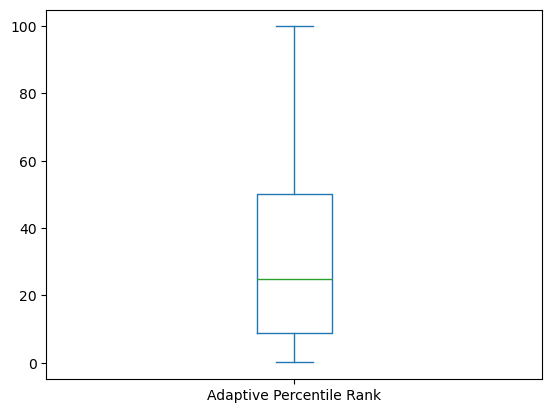

In [85]:
CBI_eligible_df['Adaptive Percentile Rank'].plot(kind='box')
plt.show()

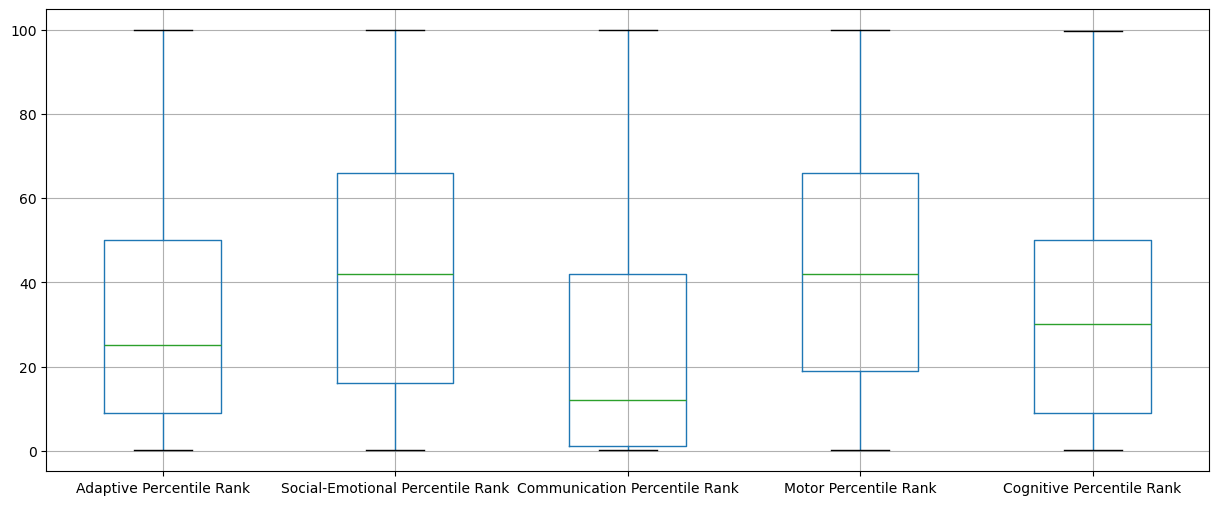

In [89]:
plt.figure(figsize=(15, 6))
CBI_eligible_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].boxplot()
plt.show()

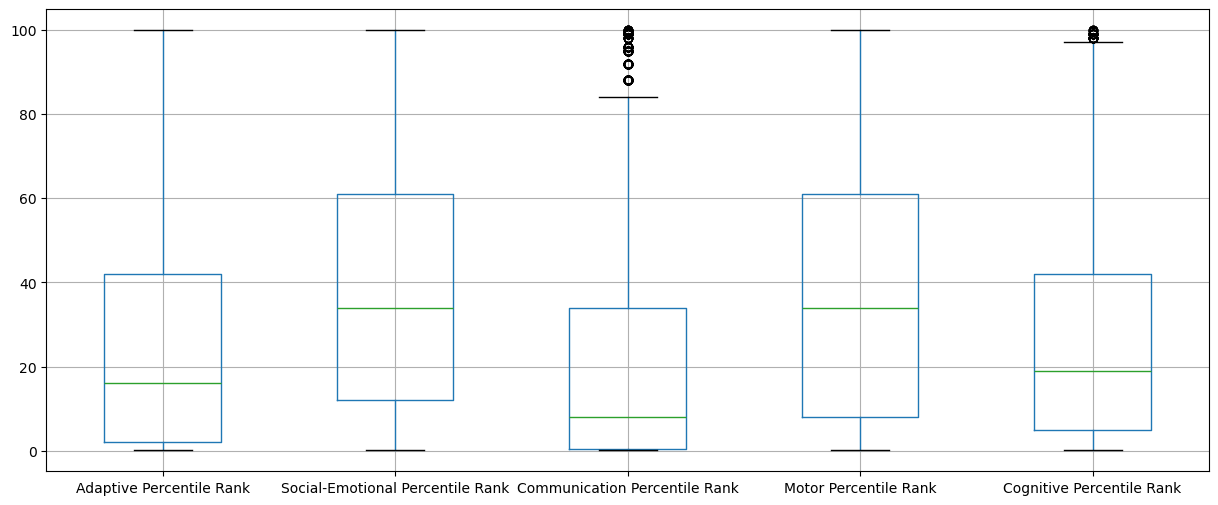

In [90]:
plt.figure(figsize=(15, 6))
CBI_annual_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].boxplot()
plt.show()

<Axes: >

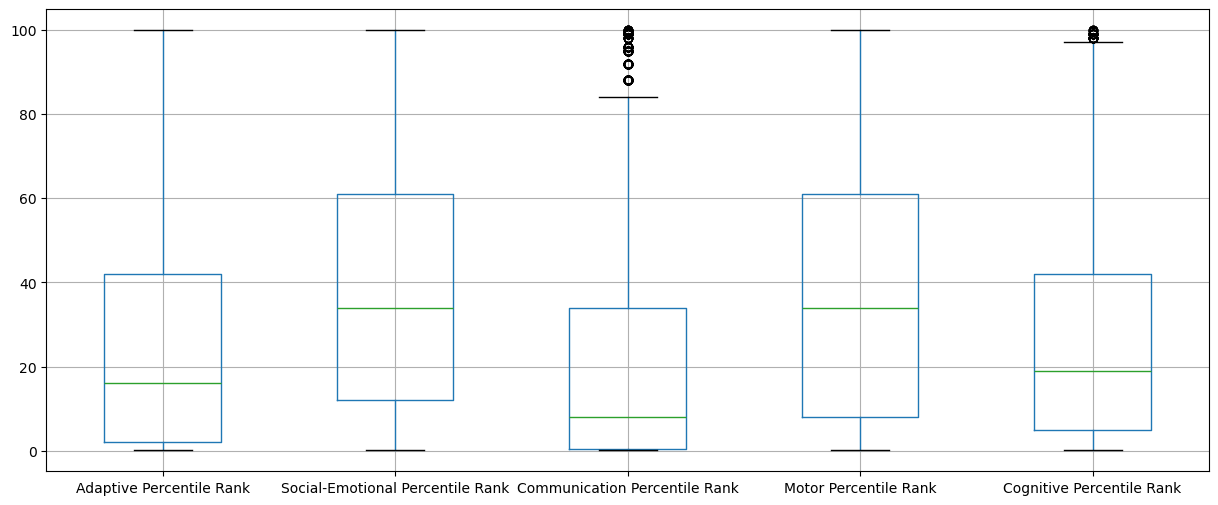

In [92]:
plt.figure(figsize=(15, 6))
CBI_annual_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].boxplot()

### Hist Plots for domain PR 

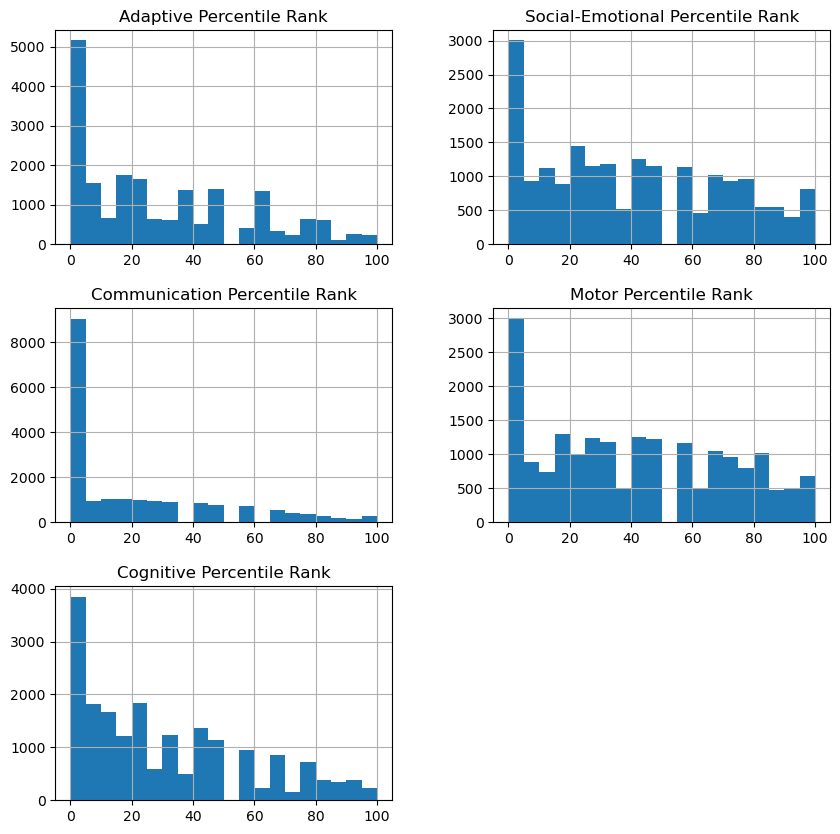

In [97]:
CBI_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].hist(bins=20,figsize=(10, 10))
plt.show()

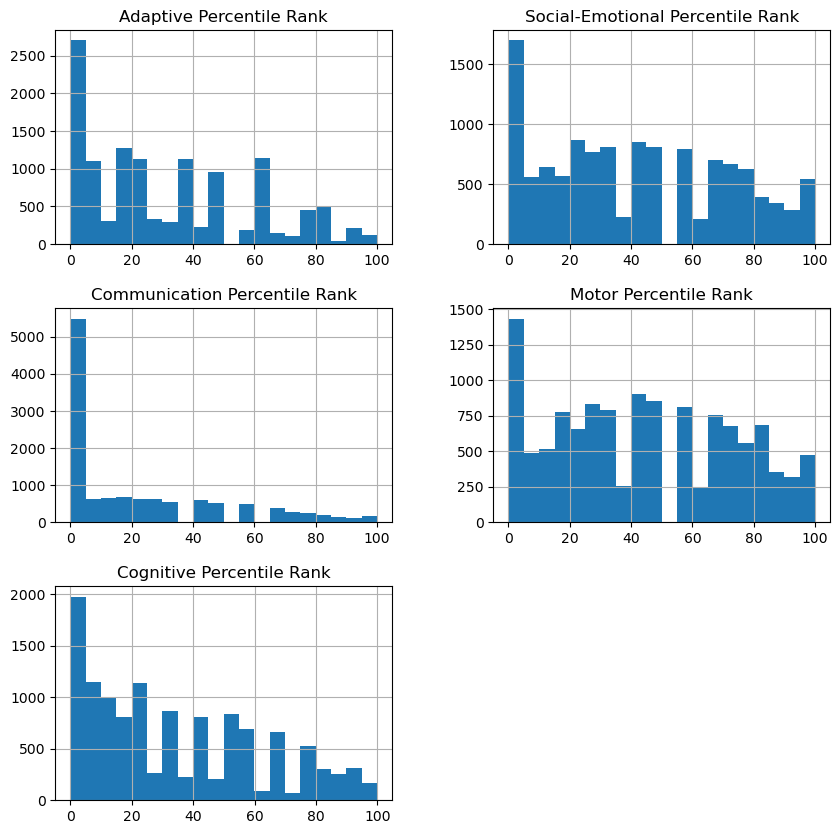

In [98]:
CBI_eligible_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].hist(bins=20,figsize=(10, 10))
plt.show()

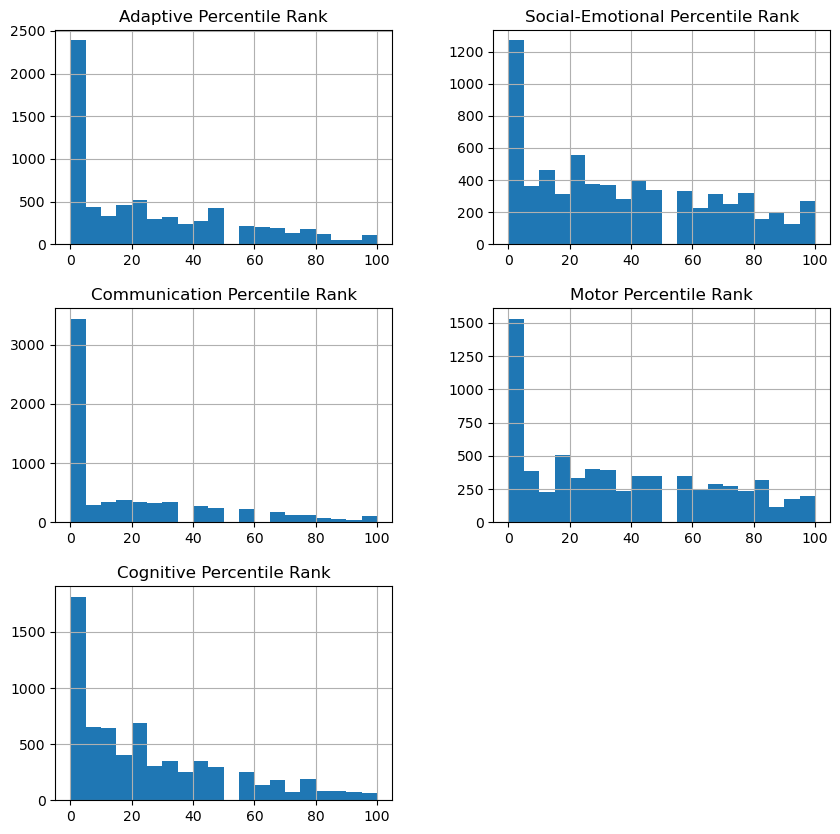

In [99]:
CBI_annual_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].hist(bins=20,figsize=(10, 10))
plt.show()

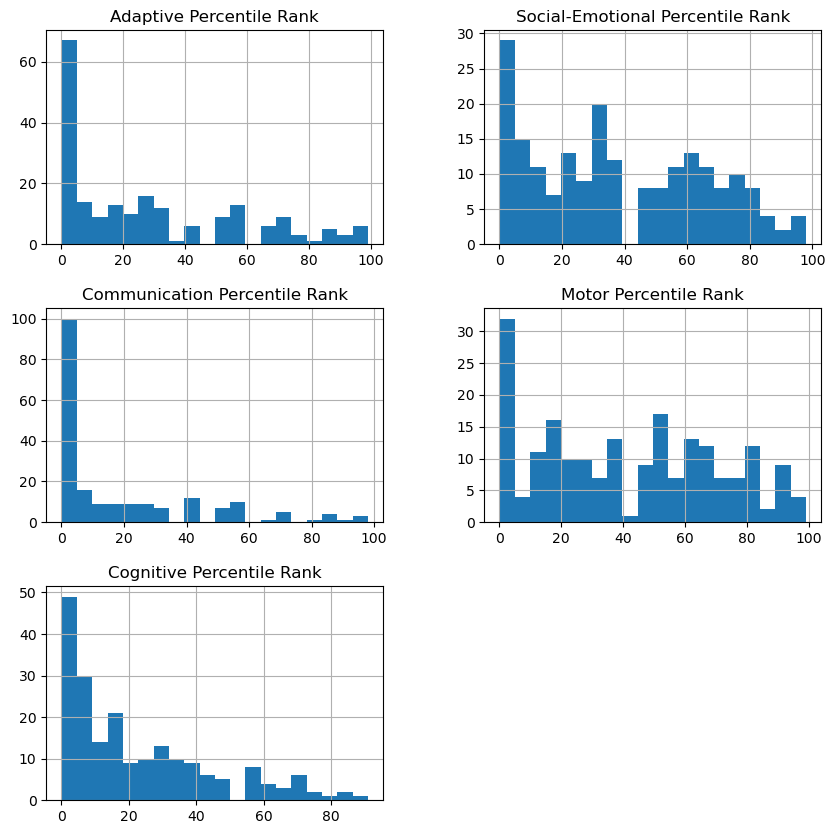

In [100]:
CBI_milestone_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].hist(bins=20,figsize=(10, 10))
plt.show()

In [102]:
round(CBI_eligible_df[['Adaptive Percentile Rank',
        'Social-Emotional Percentile Rank',
        'Communication Percentile Rank',
        'Motor Percentile Rank',
        'Cognitive Percentile Rank']].mean(),2)


Adaptive Percentile Rank            32.00
Social-Emotional Percentile Rank    42.30
Communication Percentile Rank       22.67
Motor Percentile Rank               44.37
Cognitive Percentile Rank           34.37
dtype: float64

In [125]:
# round(CBI_df.groupby('Program Label')['Adaptive Percentile Rank'].agg(['min','mean','median','max']),2)

In [126]:
# round(CBI_df.groupby('Program Label')['Social-Emotional Percentile Rank'].agg(['min','mean','median','max']),2)

In [111]:
mean_df = round(CBI_df.groupby('Program Label')[['Adaptive Percentile Rank',
                      'Social-Emotional Percentile Rank',
                      'Communication Percentile Rank',
                      'Motor Percentile Rank',
                      'Cognitive Percentile Rank']].mean().reset_index(),2)
mean_df

,Program Label,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,Cognitive Percentile Rank
0,BDI-3 Annual Evaluation,26.21,37.86,19.71,36.81,26.47
1,BDI-3 Eligibility Evaluation,32.00,42.30,22.67,44.37,34.37
2,BDI-3 Milestone or Exit Evaluation,28.34,38.40,18.59,41.54,22.84


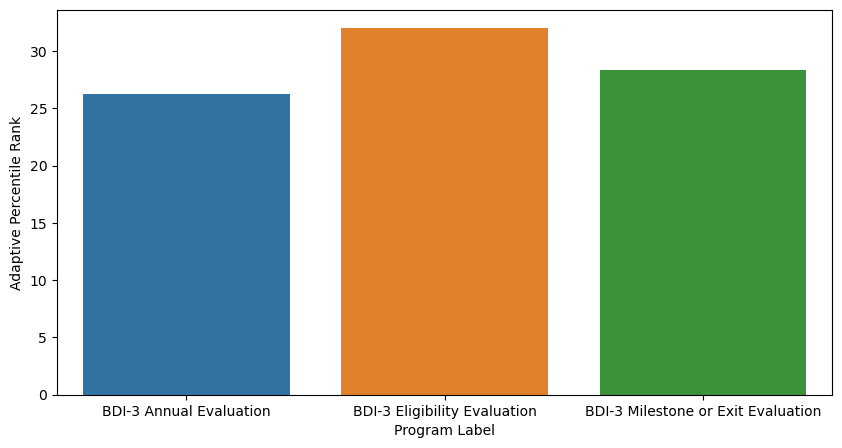

In [113]:
plt.figure(figsize=(10, 5))

mean_bar_df = sns.barplot(
    data=mean_df,
    x='Program Label',
    y='Adaptive Percentile Rank',
    hue='Program Label'
)

#date_hauler_df_bar.set_title('Missed Trash by Month')
#date_hauler_df_bar.set_xlabel('Year-Month')
#date_hauler_df_bar.set_ylabel('Missed Count')

#plt.savefig('date_hauler_df_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [114]:
mean_df_group = mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

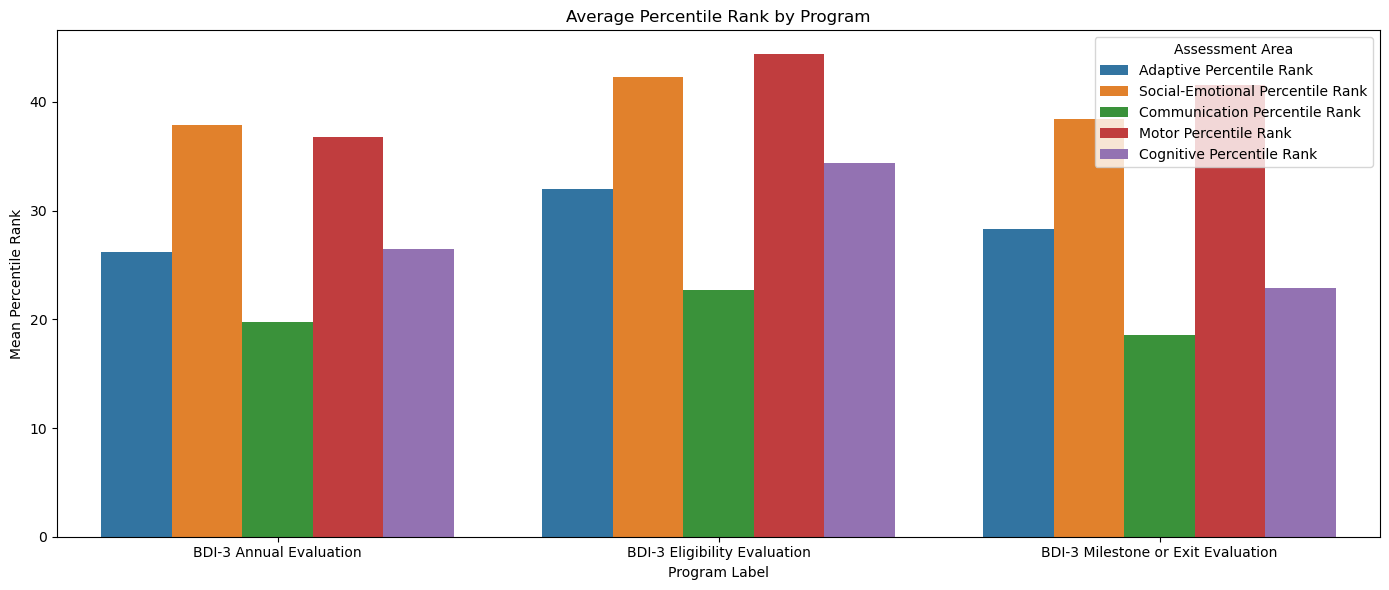

In [117]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category'
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

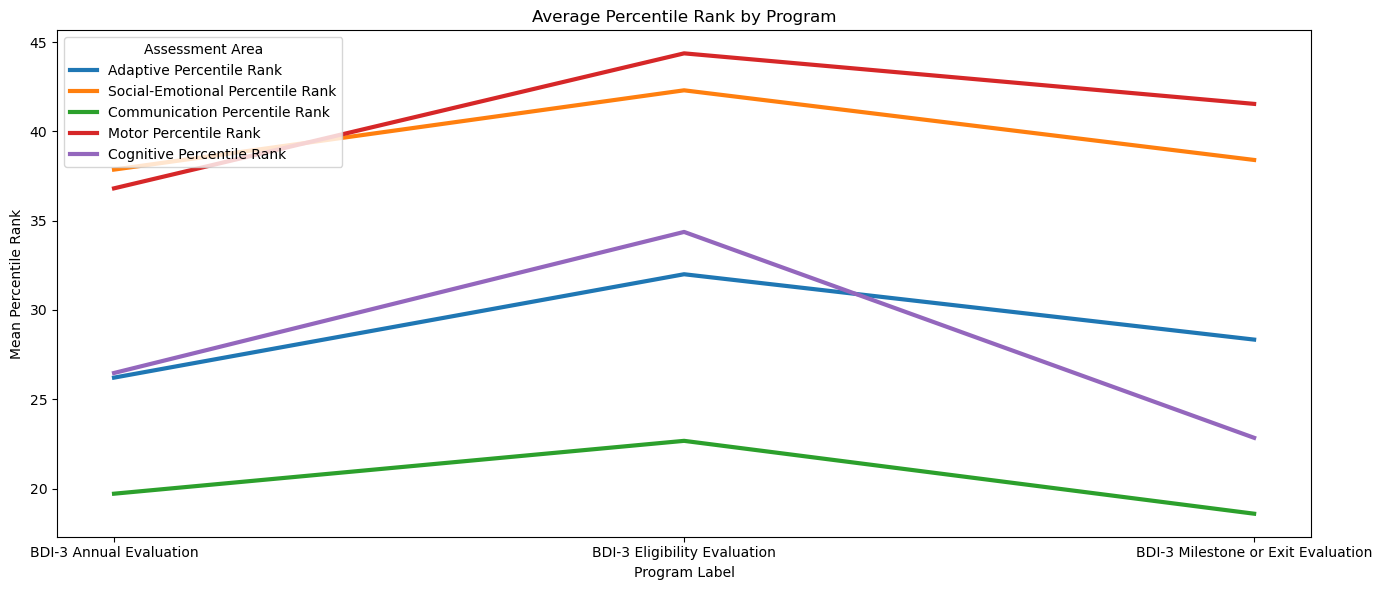

In [119]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [121]:
sub_ada_mean_df = round(CBI_df.groupby('Program Label')[['Adaptive-Self Care PR',
                      'Adaptive-Personal Responsibility PR']].mean().reset_index(),2)
sub_ada_mean_df

,Program Label,Adaptive-Self Care PR,Adaptive-Personal Responsibility PR
0,BDI-3 Annual Evaluation,22.62,34.45
1,BDI-3 Eligibility Evaluation,31.09,34.56
2,BDI-3 Milestone or Exit Evaluation,21.65,39.83


In [123]:
sub_ada_mean_df_group = sub_ada_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

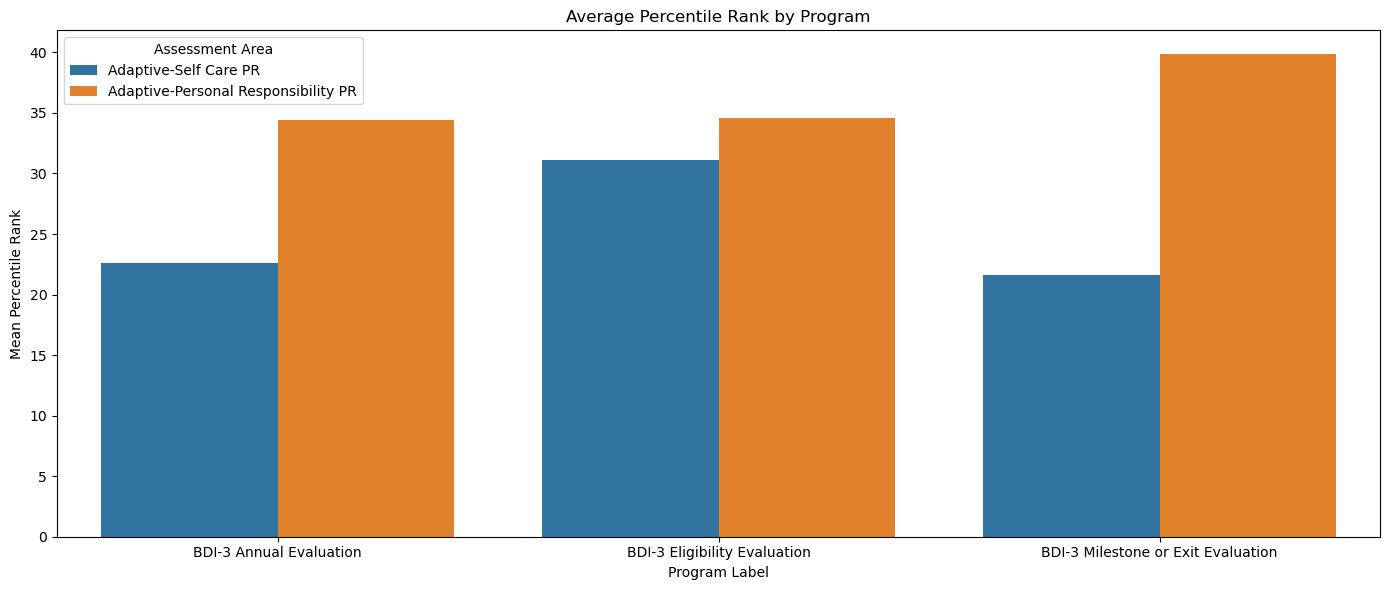

In [128]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_ada_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [132]:
sub_se_mean_df = round(CBI_df.groupby('Program Label')[['Social Emotional-Adult Interaction PR',
                      'Social Emotional-Peer Interaction PR',
                      'Social Emotional-Self Concept / Social Role PR']].mean().reset_index(),2)
sub_se_mean_df

,Program Label,Social Emotional-Adult Interaction PR,Social Emotional-Peer Interaction PR,Social Emotional-Self Concept / Social Role PR
0,BDI-3 Annual Evaluation,55.70,31.17,29.92
1,BDI-3 Eligibility Evaluation,54.92,33.01,35.29
2,BDI-3 Milestone or Exit Evaluation,57.10,37.10,28.00


In [135]:
sub_se_mean_df_group = sub_se_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

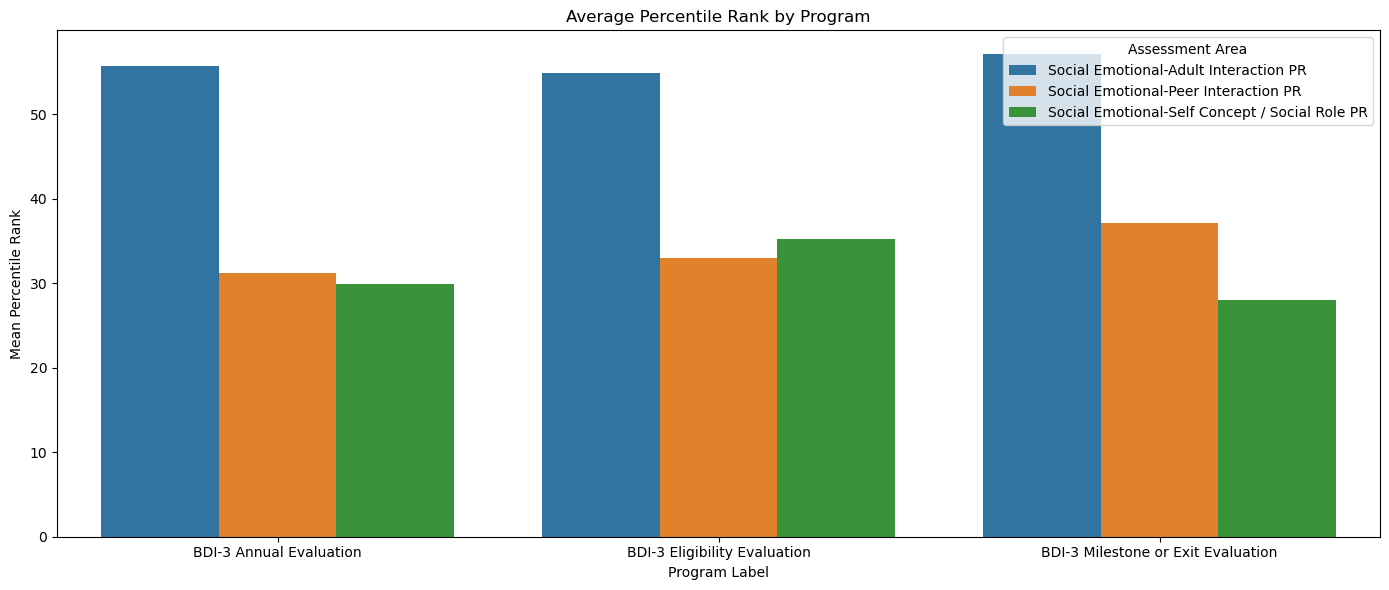

In [136]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_se_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [138]:
sub_com_mean_df = round(CBI_df.groupby('Program Label')[['Communication-Receptive Communication PR',
                      'Communication-Expressive Communication PR']].mean().reset_index(),2)
sub_com_mean_df

,Program Label,Communication-Receptive Communication PR,Communication-Expressive Communication PR
0,BDI-3 Annual Evaluation,23.14,21.37
1,BDI-3 Eligibility Evaluation,26.28,24.60
2,BDI-3 Milestone or Exit Evaluation,22.24,20.03


In [139]:
sub_com_mean_df_group = sub_com_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

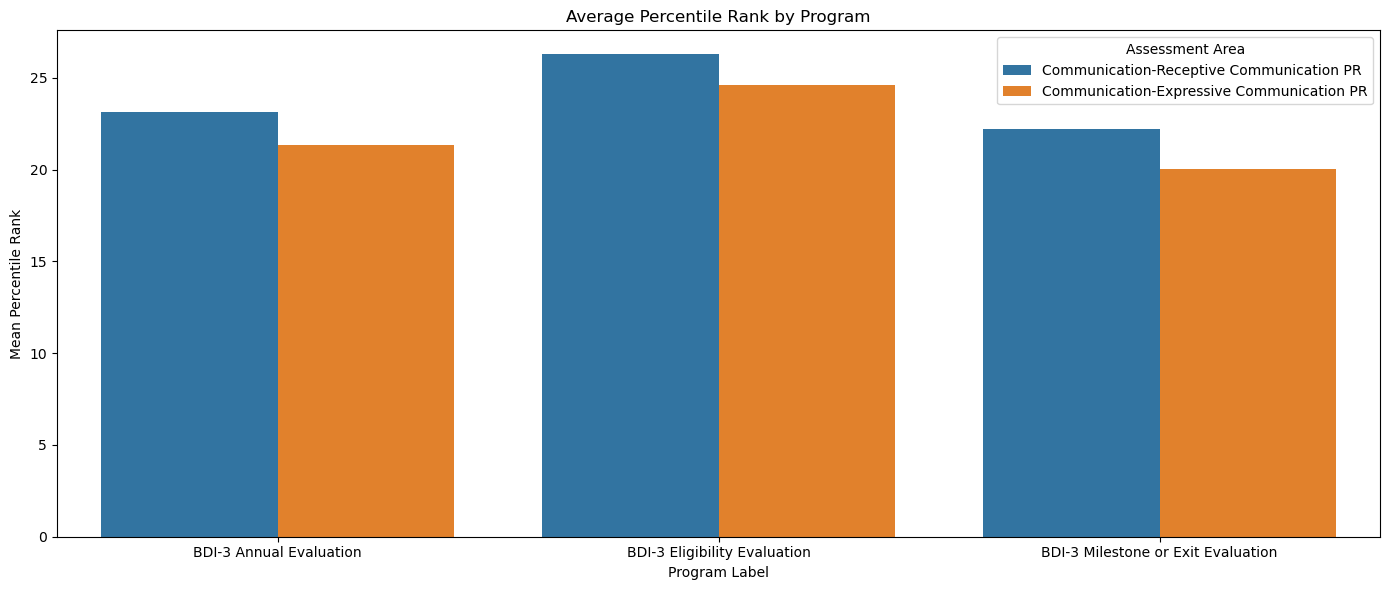

In [140]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_com_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [141]:
sub_mo_mean_df = round(CBI_df.groupby('Program Label')[['Motor-Gross Motor PR',
                      'Motor-Fine Motor PR',
                      'Motor-Perceptual Motor PR']].mean().reset_index(),2)
sub_mo_mean_df

,Program Label,Motor-Gross Motor PR,Motor-Fine Motor PR,Motor-Perceptual Motor PR
0,BDI-3 Annual Evaluation,32.61,43.93,40.01
1,BDI-3 Eligibility Evaluation,40.78,51.43,42.08
2,BDI-3 Milestone or Exit Evaluation,36.30,45.50,47.14


In [142]:
sub_mo_mean_df_group = sub_mo_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

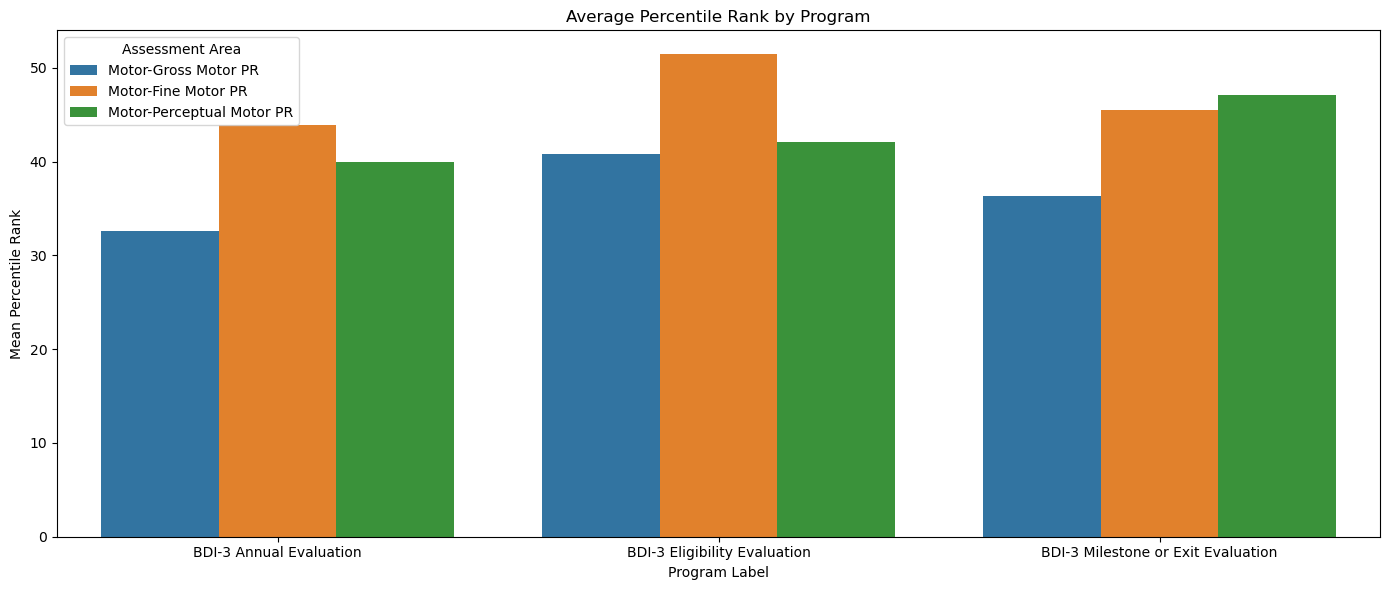

In [143]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_mo_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [144]:
sub_cog_mean_df = round(CBI_df.groupby('Program Label')[['Cognitive-Attention and Memory PR',
                      'Cognitive-Reasoning / Academic Skills PR',
                      'Cognitive-Perception and Concepts PR']].mean().reset_index(),2)
sub_cog_mean_df

,Program Label,Cognitive-Attention and Memory PR,Cognitive-Reasoning / Academic Skills PR,Cognitive-Perception and Concepts PR
0,BDI-3 Annual Evaluation,30.51,34.01,24.49
1,BDI-3 Eligibility Evaluation,37.51,34.00,35.05
2,BDI-3 Milestone or Exit Evaluation,27.92,31.92,20.55


In [145]:
sub_cog_mean_df_group = sub_cog_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

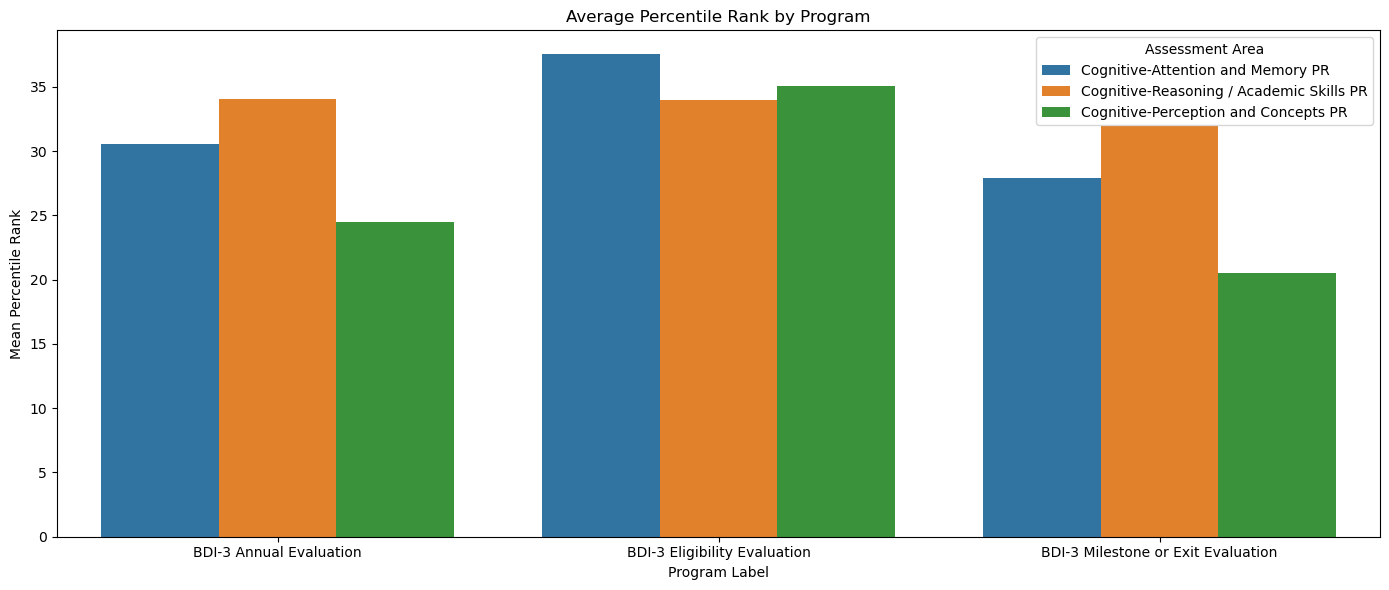

In [146]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_cog_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [151]:
sub_all_mean_df = round(CBI_df.groupby('Program Label')[['Adaptive-Self Care PR',
                      'Adaptive-Personal Responsibility PR',
                      'Social Emotional-Adult Interaction PR',
                      'Social Emotional-Peer Interaction PR',
                      'Social Emotional-Self Concept / Social Role PR',
                      'Communication-Receptive Communication PR',
                      'Communication-Expressive Communication PR',
                      'Motor-Gross Motor PR',
                      'Motor-Fine Motor PR',
                      'Motor-Perceptual Motor PR',
                      'Cognitive-Attention and Memory PR',
                      'Cognitive-Reasoning / Academic Skills PR', 
                      'Cognitive-Perception and Concepts PR']].mean().reset_index(),2)
sub_all_mean_df

,Program Label,Adaptive-Self Care PR,Adaptive-Personal Responsibility PR,Social Emotional-Adult Interaction PR,Social Emotional-Peer Interaction PR,Social Emotional-Self Concept / Social Role PR,Communication-Receptive Communication PR,Communication-Expressive Communication PR,Motor-Gross Motor PR,Motor-Fine Motor PR,Motor-Perceptual Motor PR,Cognitive-Attention and Memory PR,Cognitive-Reasoning / Academic Skills PR,Cognitive-Perception and Concepts PR
0,BDI-3 Annual Evaluation,22.62,34.45,55.70,31.17,29.92,23.14,21.37,32.61,43.93,40.01,30.51,34.01,24.49
1,BDI-3 Eligibility Evaluation,31.09,34.56,54.92,33.01,35.29,26.28,24.60,40.78,51.43,42.08,37.51,34.00,35.05
2,BDI-3 Milestone or Exit Evaluation,21.65,39.83,57.10,37.10,28.00,22.24,20.03,36.30,45.50,47.14,27.92,31.92,20.55


In [152]:
sub_all_mean_df_group = sub_all_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

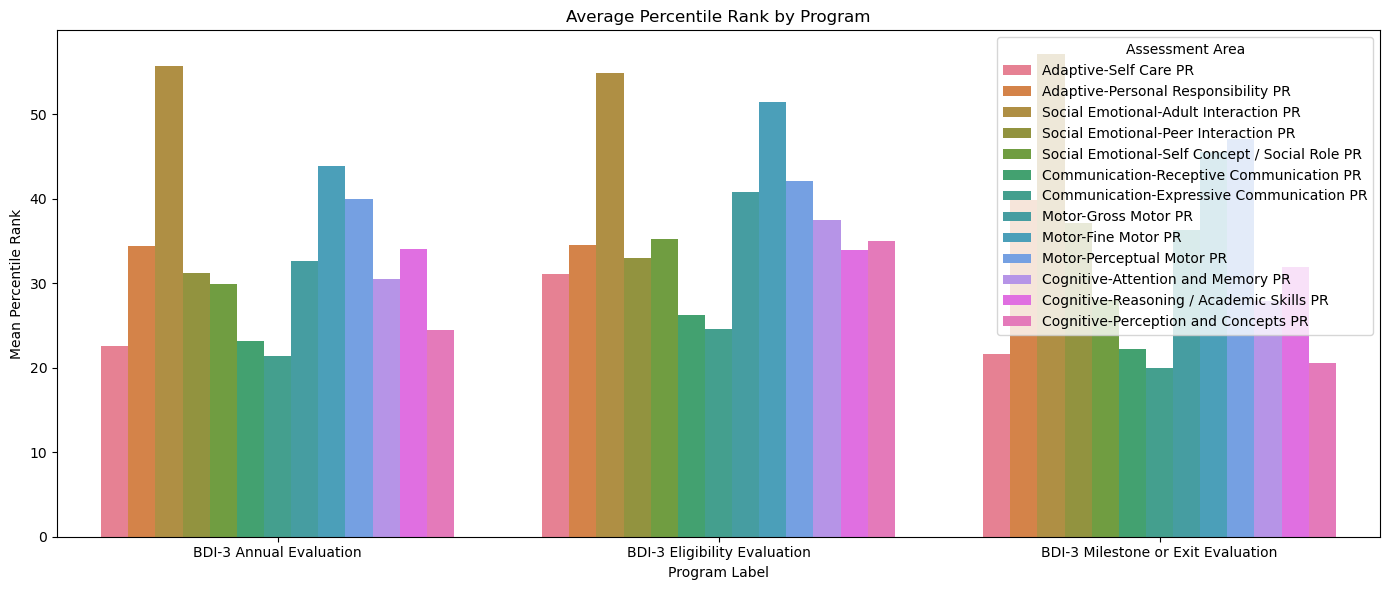

In [153]:
plt.figure(figsize=(14, 6))

sns.barplot(
    data=sub_all_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    linewidth=3
)

plt.title('Average Percentile Rank by Program')
plt.xlabel('Program Label')
plt.ylabel('Mean Percentile Rank')

plt.legend(title='Assessment Area')

plt.tight_layout()
plt.show()

In [154]:
pr_columns = [
    'Adaptive-Self Care PR',
    'Adaptive-Personal Responsibility PR',
    'Social Emotional-Adult Interaction PR',
    'Social Emotional-Peer Interaction PR',
    'Social Emotional-Self Concept / Social Role PR',
    'Communication-Receptive Communication PR',
    'Communication-Expressive Communication PR',
    'Motor-Gross Motor PR',
    'Motor-Fine Motor PR',
    'Motor-Perceptual Motor PR',
    'Cognitive-Attention and Memory PR',
    'Cognitive-Reasoning / Academic Skills PR',
    'Cognitive-Perception and Concepts PR'
]

In [155]:
sub_all_mean_df = CBI_df.groupby('Program Label')[pr_columns].mean()

sub_all_mean_df['Mean PR'] = sub_all_mean_df.mean(axis=1)

sub_all_mean_df = (
    round(sub_all_mean_df.sort_values('Mean PR', ascending=False), 2)
    .reset_index()
)

In [156]:
sub_all_mean_df

,Program Label,Adaptive-Self Care PR,Adaptive-Personal Responsibility PR,Social Emotional-Adult Interaction PR,Social Emotional-Peer Interaction PR,Social Emotional-Self Concept / Social Role PR,Communication-Receptive Communication PR,Communication-Expressive Communication PR,Motor-Gross Motor PR,Motor-Fine Motor PR,Motor-Perceptual Motor PR,Cognitive-Attention and Memory PR,Cognitive-Reasoning / Academic Skills PR,Cognitive-Perception and Concepts PR,Mean PR
0,BDI-3 Eligibility Evaluation,31.09,34.56,54.92,33.01,35.29,26.28,24.60,40.78,51.43,42.08,37.51,34.00,35.05,36.97
1,BDI-3 Milestone or Exit Evaluation,21.65,39.83,57.10,37.10,28.00,22.24,20.03,36.30,45.50,47.14,27.92,31.92,20.55,33.48
2,BDI-3 Annual Evaluation,22.62,34.45,55.70,31.17,29.92,23.14,21.37,32.61,43.93,40.01,30.51,34.01,24.49,32.61


In [160]:
sub_all_mean_df_group = sub_all_mean_df.melt(
    id_vars='Program Label',
    var_name='Category',
    value_name='Mean Percentile Rank'
)

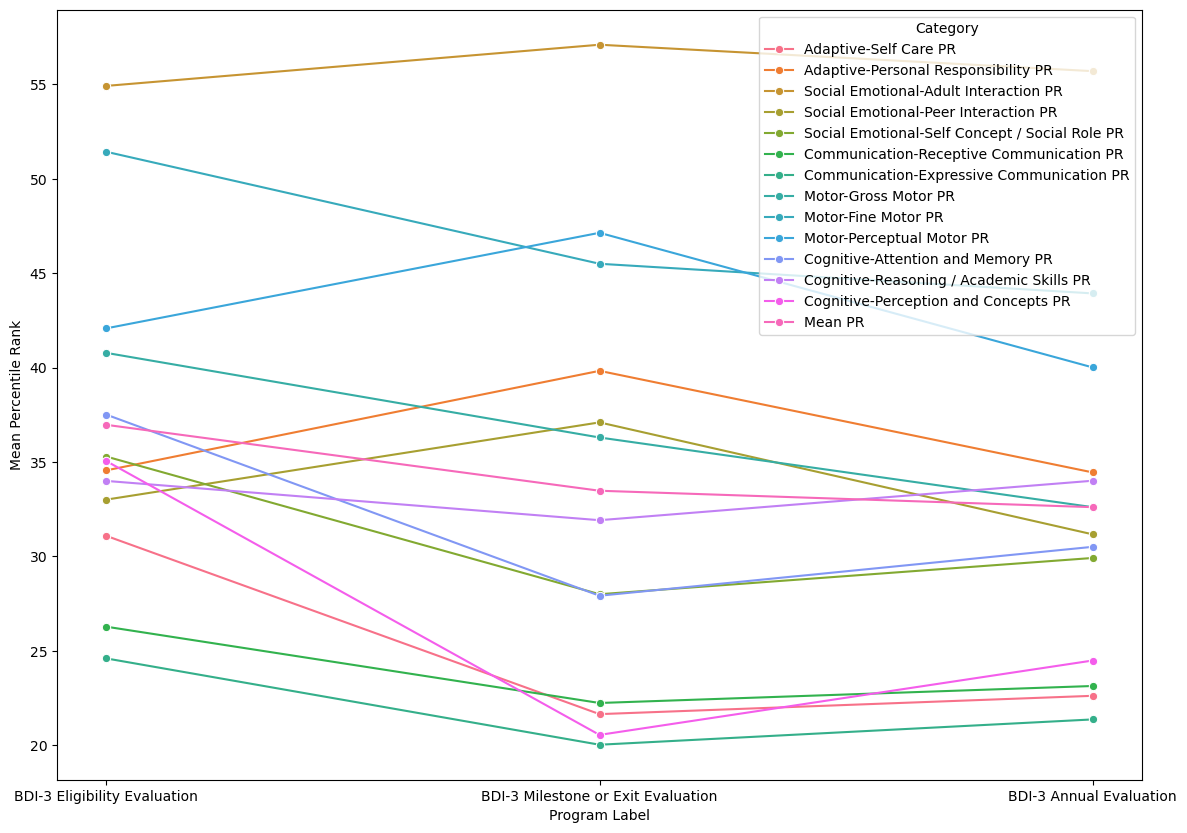

In [165]:
plt.figure(figsize=(14, 10))
sns.lineplot(
    data=sub_all_mean_df_group,
    x='Program Label',
    y='Mean Percentile Rank',
    hue='Category',
    marker='o'
);

In [182]:
adapt_cat = []

for pr in CBI_df['Adaptive Percentile Rank']:
    if pd.isna(pr):
        adaptive_cat.append('Missing')
    elif pr <= 33:
        adaptive_cat.append('Low')
    elif pr <= 66:
        adaptive_cat.append('Med')
    else:
        adaptive_cat.append('High')

CBI_df['Adaptive_Cat'] = adaptive_cat
CBI_df.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Adaptive_Cat
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16.0,77-97,...,13.0,84.0,12.0,98/90,411.0,392 - 431,1.0,60.0,71.0,Low
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21.0,82-96,...,7.0,16.0,18.0,29/90,437.0,421 - 453,-1.0,40.0,29.0,Low
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25.0,81-101,...,7.0,16.0,15.0,37/90,426.0,408 - 444,-1.0,40.0,29.0,Low
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84.0,103-123,...,10.0,50.0,12.0,92/90,411.0,392 - 431,0.0,50.0,50.0,High
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5.0,68-88,...,10.0,50.0,15.0,88/90,426.0,408 - 444,0.0,50.0,50.0,Low


In [185]:
se_cat = []

for pr in CBI_df['Social-Emotional Percentile Rank']:
    if pd.isna(pr):
        se_cat.append('Missing')
    elif pr <= 33:
        se_cat.append('Low')
    elif pr <= 66:
        se_cat.append('Med')
    else:
        se_cat.append('High')

CBI_df['se_cat'] = se_cat
CBI_df.head()

C:\Users\therb\AppData\Local\Temp\ipykernel_61436\3475502460.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CBI_df['se_cat'] = se_cat


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Adaptive_Cat,se_cat
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16.0,77-97,...,84.0,12.0,98/90,411.0,392 - 431,1.0,60.0,71.0,Low,High
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21.0,82-96,...,16.0,18.0,29/90,437.0,421 - 453,-1.0,40.0,29.0,Low,Med
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25.0,81-101,...,16.0,15.0,37/90,426.0,408 - 444,-1.0,40.0,29.0,Low,Low
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84.0,103-123,...,50.0,12.0,92/90,411.0,392 - 431,0.0,50.0,50.0,High,Med
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5.0,68-88,...,50.0,15.0,88/90,426.0,408 - 444,0.0,50.0,50.0,Low,Low


In [186]:
com_cat = []

for pr in CBI_df['Communication Percentile Rank']:
    if pd.isna(pr):
        com_cat.append('Missing')
    elif pr <= 33:
        com_cat.append('Low')
    elif pr <= 66:
        com_cat.append('Med')
    else:
        com_cat.append('High')

CBI_df['com_cat'] = com_cat
CBI_df.head()

C:\Users\therb\AppData\Local\Temp\ipykernel_61436\2284518208.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CBI_df['com_cat'] = com_cat


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Adaptive_Cat,se_cat,com_cat
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16.0,77-97,...,12.0,98/90,411.0,392 - 431,1.0,60.0,71.0,Low,High,Low
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21.0,82-96,...,18.0,29/90,437.0,421 - 453,-1.0,40.0,29.0,Low,Med,Med
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25.0,81-101,...,15.0,37/90,426.0,408 - 444,-1.0,40.0,29.0,Low,Low,Low
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84.0,103-123,...,12.0,92/90,411.0,392 - 431,0.0,50.0,50.0,High,Med,Low
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5.0,68-88,...,15.0,88/90,426.0,408 - 444,0.0,50.0,50.0,Low,Low,Low


In [187]:
motor_cat = []

for pr in CBI_df['Motor Percentile Rank']:
    if pd.isna(pr):
        motor_cat.append('Missing')
    elif pr <= 33:
        motor_cat.append('Low')
    elif pr <= 66:
        motor_cat.append('Med')
    else:
        motor_cat.append('High')

CBI_df['motor_cat'] = motor_cat
CBI_df.head()

C:\Users\therb\AppData\Local\Temp\ipykernel_61436\2519726599.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CBI_df['motor_cat'] = motor_cat


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Adaptive_Cat,se_cat,com_cat,motor_cat
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16.0,77-97,...,98/90,411.0,392 - 431,1.0,60.0,71.0,Low,High,Low,Low
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21.0,82-96,...,29/90,437.0,421 - 453,-1.0,40.0,29.0,Low,Med,Med,Med
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25.0,81-101,...,37/90,426.0,408 - 444,-1.0,40.0,29.0,Low,Low,Low,High
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84.0,103-123,...,92/90,411.0,392 - 431,0.0,50.0,50.0,High,Med,Low,Low
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5.0,68-88,...,88/90,426.0,408 - 444,0.0,50.0,50.0,Low,Low,Low,Low


In [188]:
cog_cat = []

for pr in CBI_df['Cognitive Percentile Rank']:
    if pd.isna(pr):
        cog_cat.append('Missing')
    elif pr <= 33:
        cog_cat.append('Low')
    elif pr <= 66:
        cog_cat.append('Med')
    else:
        cog_cat.append('High')

CBI_df['cog_cat'] = cog_cat
CBI_df.head()

C:\Users\therb\AppData\Local\Temp\ipykernel_61436\1126865181.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  CBI_df['cog_cat'] = cog_cat


,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,Adaptive_Cat,se_cat,com_cat,motor_cat,cog_cat
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16.0,77-97,...,411.0,392 - 431,1.0,60.0,71.0,Low,High,Low,Low,Med
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21.0,82-96,...,437.0,421 - 453,-1.0,40.0,29.0,Low,Med,Med,Med,Med
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25.0,81-101,...,426.0,408 - 444,-1.0,40.0,29.0,Low,Low,Low,High,Low
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84.0,103-123,...,411.0,392 - 431,0.0,50.0,50.0,High,Med,Low,Low,High
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5.0,68-88,...,426.0,408 - 444,0.0,50.0,50.0,Low,Low,Low,Low,Med
